# 🫁 Dataset 3: Chest X-Ray Pneumonia Detection — ResNet50
## Kỹ thuật: ResNet50 Transfer Learning + Binary Classification

**Pipeline:** Dataset Analysis → Class Distribution → Build ResNet50 → Train → ROC-AUC → GradCAM

---

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

TRAIN_DIR = '../data/chest_xray/chest_xray/train'
VAL_DIR   = '../data/chest_xray/chest_xray/val'
TEST_DIR  = '../data/chest_xray/chest_xray/test'
SAVE_DIR  = '../results/chest_xray'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 15
CLASSES    = ['NORMAL', 'PNEUMONIA']

print(f'TF: {tf.__version__}')

2026-05-28 12:20:42.742237: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 12:20:42.770669: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 12:20:43.262017: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0


## 📊 1. Dataset Analysis

In [2]:
def count_split(split_dir):
    return {c: len(os.listdir(os.path.join(split_dir, c)))
            for c in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, c))}

splits = {'Train': count_split(TRAIN_DIR),
          'Test':  count_split(TEST_DIR)}
if os.path.exists(VAL_DIR):
    splits['Val'] = count_split(VAL_DIR)

print('=== DATASET DISTRIBUTION ===')
for split, counts in splits.items():
    total = sum(counts.values())
    print(f'{split:8s}: Total={total:,}', end=' | ')
    for cls, n in counts.items():
        print(f'{cls}={n:,}({n/total*100:.1f}%)', end=' ')
    print()

=== DATASET DISTRIBUTION ===
Train   : Total=5,216 | PNEUMONIA=3,875(74.3%) NORMAL=1,341(25.7%) 
Test    : Total=624 | PNEUMONIA=390(62.5%) NORMAL=234(37.5%) 
Val     : Total=16 | PNEUMONIA=8(50.0%) NORMAL=8(50.0%) 


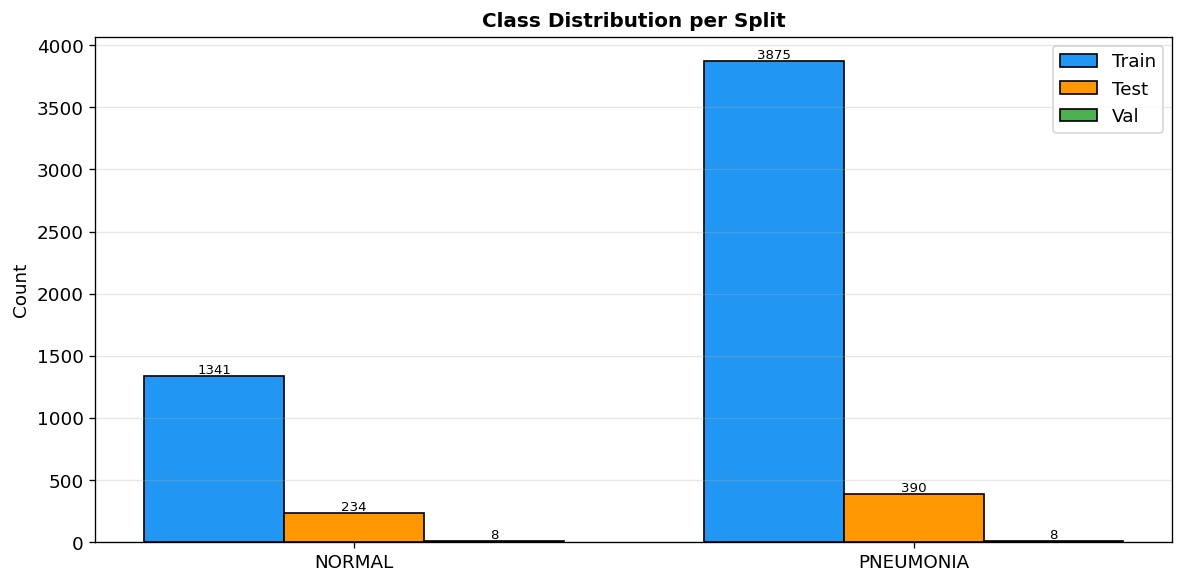

In [3]:
# PLOT 1: CLASS DISTRIBUTION
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CLASSES))
w = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']

for i, ((name, cnt), color) in enumerate(zip(splits.items(), colors)):
    vals = [cnt.get(c, 0) for c in CLASSES]

    bars = ax.bar(x + (i - 1) * w, vals, w,
                  label=name, color=color, edgecolor='black')

    for b in bars:
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + 20,
                int(b.get_height()),
                ha='center', fontsize=8)

ax.set(
    title='Class Distribution per Split',
    xticks=x,
    xticklabels=CLASSES,
    ylabel='Count'
)

ax.legend()
ax.grid(axis='y', alpha=.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_distribution.png', dpi=300)
plt.show()

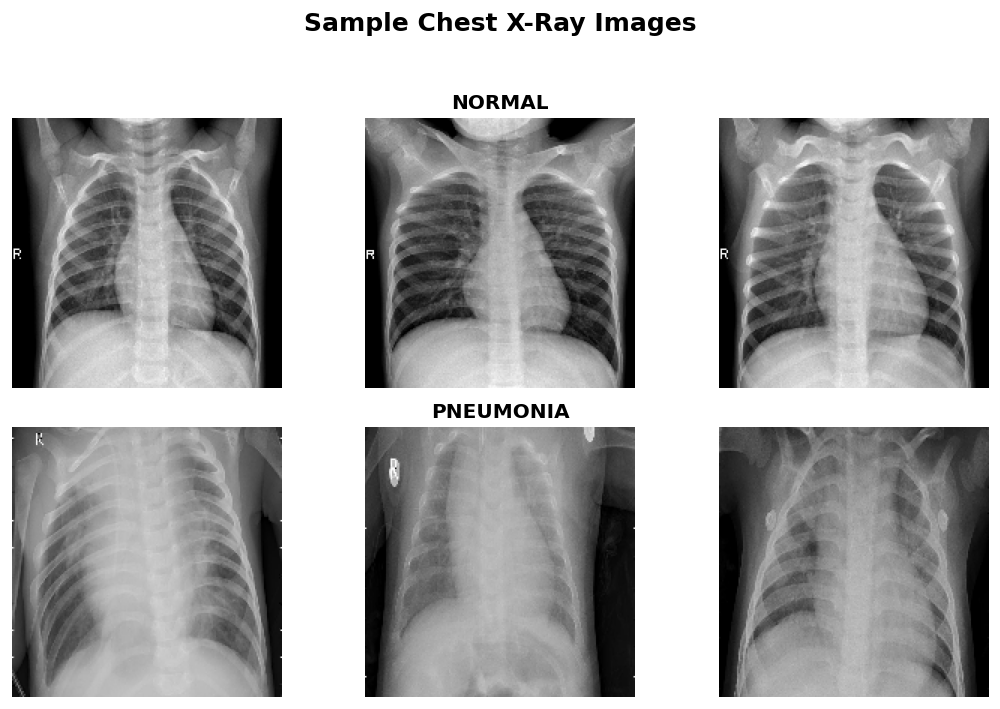

In [4]:
# PLOT 2: SAMPLE IMAGES
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 6))

for r, cls in enumerate(CLASSES):
    imgs = os.listdir(os.path.join(TRAIN_DIR, cls))[:3]

    for c, img_name in enumerate(imgs):
        ax = axes[r, c]

        img = load_img(
            os.path.join(TRAIN_DIR, cls, img_name),
            target_size=(180, 180)
        )

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        if c == 1:
            ax.set_title(cls, fontweight='bold')

plt.suptitle('Sample Chest X-Ray Images', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, .95])

plt.savefig(f'{SAVE_DIR}/02_sample_images.png', dpi=300)
plt.show()

In [5]:
# fig=plt.figure(figsize=(16,8))
# gs=fig.add_gridspec(2,5,width_ratios=[1.6,1.6,1,1,1],wspace=.28,hspace=.25)

# ax=fig.add_subplot(gs[:,0:2])
# x=np.arange(len(CLASSES)); w=.22
# colors={'Train':'#2196F3','Val':'#FF9800','Test':'#4CAF50'}

# for i,(sp,cnt) in enumerate(splits.items()):
#     vals=[cnt.get(c,0) for c in CLASSES]
#     bars=ax.bar(x+(i-1)*w,vals,w,label=sp,color=colors[sp],edgecolor='black')
#     for b in bars:
#         ax.text(b.get_x()+b.get_width()/2,b.get_height()+20,int(b.get_height()),
#                 ha='center',fontsize=9)

# ax.set_title('Class Distribution per Split')
# ax.set_xticks(x)
# ax.set_xticklabels(CLASSES,fontweight='bold')
# ax.set_ylabel('Count')
# ax.legend()
# ax.grid(axis='y',alpha=.3)

# for r,cls in enumerate(CLASSES):
#     imgs=os.listdir(os.path.join(TRAIN_DIR,cls))[:3]
#     for c in range(3):
#         ax=fig.add_subplot(gs[r,c+2])
#         img=load_img(os.path.join(TRAIN_DIR,cls,imgs[c]),target_size=(180,180))
#         ax.imshow(img,cmap='gray')
#         ax.axis('off')
#         if c==1: ax.set_title(cls,fontweight='bold')

# plt.suptitle('Chest X-Ray Dataset Overview',fontsize=16,fontweight='bold')
# plt.tight_layout(rect=[0,0,1,.96])
# plt.savefig(f'{SAVE_DIR}/01_dataset_overview.png',dpi=300,bbox_inches='tight')
# plt.show()

## 🏗️ 2. Build ResNet50 Model

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary',
    seed=SEED)
test_gen  = test_datagen.flow_from_directory(
    TEST_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False,
    seed=SEED)

# Class weights for imbalance
n_normal    = train_gen.classes.tolist().count(0)
n_pneumonia = train_gen.classes.tolist().count(1)
total_n     = n_normal + n_pneumonia
class_weights = {0: total_n / (2 * n_normal), 1: total_n / (2 * n_pneumonia)}
print(f'Class weights: {class_weights}')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='ResNet50_ChestXRay')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

2026-05-28 12:20:45.936699: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-28 12:20:45.942097: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-28 12:20:45.951196: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "ResNet50_ChestXRay"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)          

## 🚀 3. Training

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=5,
                                      restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=2, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=test_gen,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
163/163 [==============================] - 57s 341ms/step - loss: 0.4512 - accuracy: 0.7778 - auc: 0.8894 - val_loss: 0.6649 - val_accuracy: 0.6154 - val_auc: 0.8907 - lr: 1.0000e-04
Epoch 2/15
163/163 [==============================] - 52s 320ms/step - loss: 0.3579 - accuracy: 0.8374 - auc: 0.9323 - val_loss: 0.6473 - val_accuracy: 0.5721 - val_auc: 0.9089 - lr: 1.0000e-04
Epoch 3/15
163/163 [==============================] - 53s 324ms/step - loss: 0.3255 - accuracy: 0.8604 - auc: 0.9417 - val_loss: 0.4680 - val_accuracy: 0.8413 - val_auc: 0.9174 - lr: 1.0000e-04
Epoch 4/15
163/163 [==============================] - 52s 321ms/step - loss: 0.3039 - accuracy: 0.8723 - auc: 0.9473 - val_loss: 0.4020 - val_accuracy: 0.8109 - val_auc: 0.9195 - lr: 1.0000e-04
Epoch 5/15
163/163 [==============================] - 52s 321ms/step - loss: 0.2788 - accuracy: 0.8848 - auc: 0.9544 - val_loss: 0.3780 - val_accuracy: 0.8221 - val_auc: 0.9264 - lr: 1.0000e-04
Epoch 6/15
163/163 [==========

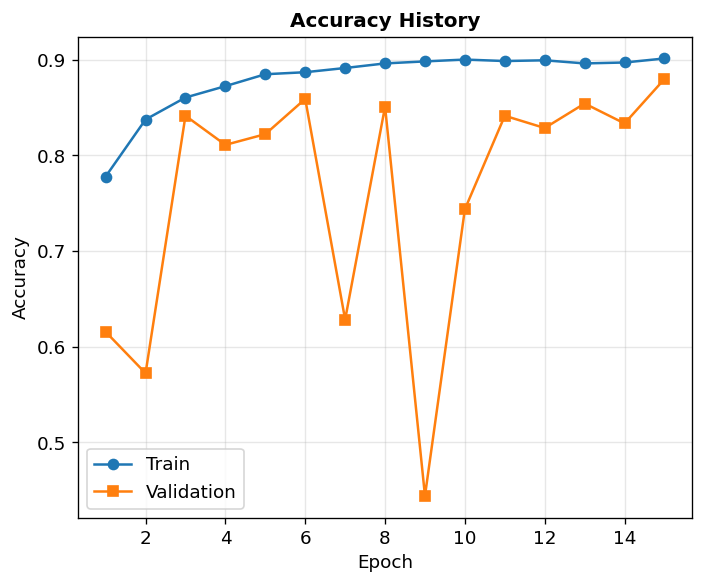

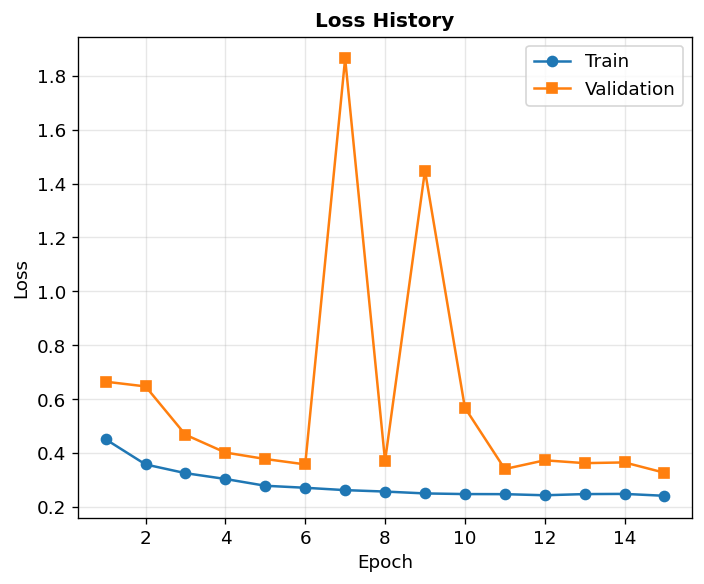

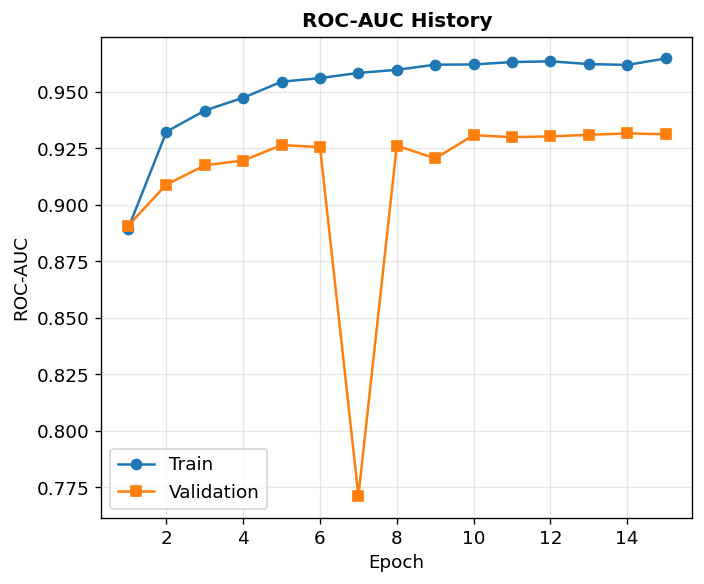

In [9]:
eps = range(1, len(history.history['accuracy']) + 1)

for tr, vl, title, file in [
    ('accuracy', 'val_accuracy', 'Accuracy', '03_accuracy.png'),
    ('loss', 'val_loss', 'Loss', '04_loss.png'),
    ('auc', 'val_auc', 'ROC-AUC', '05_auc.png')
]:

    plt.figure(figsize=(6, 5))

    plt.plot(eps, history.history[tr], 'o-', label='Train')
    plt.plot(eps, history.history[vl], 's-', label='Validation')

    plt.title(f'{title} History')
    plt.xlabel('Epoch')
    plt.ylabel(title)

    plt.grid(alpha=.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/{file}', dpi=300)
    plt.show()

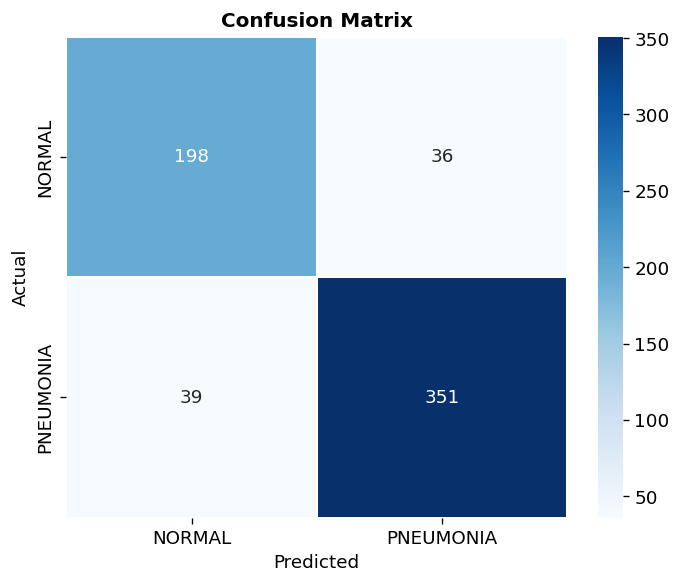

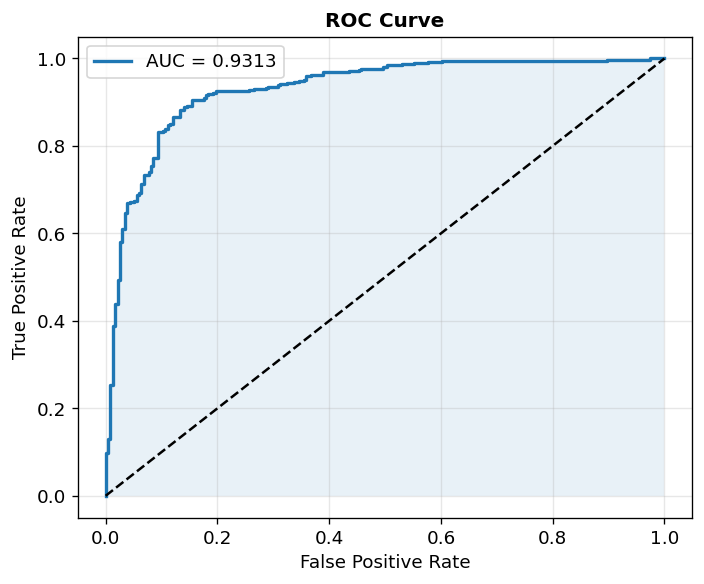

              precision    recall  f1-score   support

      NORMAL       0.84      0.85      0.84       234
   PNEUMONIA       0.91      0.90      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.87      0.87       624
weighted avg       0.88      0.88      0.88       624

ROC-AUC: 0.9313


In [10]:
# Evaluate
test_gen.reset()

y_prob = model.predict(test_gen, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)


# =======================
# Confusion Matrix
# =======================

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    linewidths=1
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06_confusion_matrix.png', dpi=300)
plt.show()


# =======================
# ROC Curve
# =======================

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, lw=2,
         label=f'AUC = {roc_auc:.4f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.fill_between(fpr, tpr, alpha=.1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid(alpha=.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_roc_curve.png', dpi=300)
plt.show()


print(classification_report(
    y_true,
    y_pred,
    target_names=CLASSES
))

print(f'ROC-AUC: {roc_auc:.4f}')

In [11]:
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Chest X-Ray Pneumonia Detection — ResNet50\n' + '='*50 + '\n')
    f.write(f'ROC-AUC: {roc_auc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=CLASSES))

print('✅ Chest X-Ray ResNet50 Experiment Completed! Results saved to', SAVE_DIR)

✅ Chest X-Ray ResNet50 Experiment Completed! Results saved to ../results/chest_xray
